In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, average_precision_score
)
import warnings
import shap 
warnings.filterwarnings('ignore')

In [2]:
shap.__version__

'0.52.0'

In [6]:
# Load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Handle missing values in TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'], inplace=True)

# Separate features and target
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [7]:
class TelcoFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, new_customer_threshold=6, loyal_customer_threshold=24):
        self.new_customer_threshold = new_customer_threshold
        self.loyal_customer_threshold = loyal_customer_threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # ==============================
        # a) AvgChargePerMonth = TotalCharges / tenure
        # ==============================
        X['AvgChargePerMonth'] = X['TotalCharges'] / X['tenure'].replace(0, 1)

        # ==============================
        # b) CLV = MonthlyCharges × tenure
        # ==============================
        X['CLV'] = X['MonthlyCharges'] * X['tenure']

        # ==============================
        # c) IsMonthContract (Contract Risk)
        # ==============================
        X['IsMonthContract'] = (X['Contract'] == 'Month-to-month').astype(int)

        # ==============================
        # d) Interaction: PaperlessBilling × AutoPay (or PaymentMethod)
        #    (AutoPay already defined from PaymentMethod)
        # ==============================
        # First define AutoPay if not already done
        X['AutoPay'] = X['PaymentMethod'].str.contains('automatic', case=False).astype(int)
        # Then interaction
        X['Paperless_AutoPay_Interaction'] = (
            (X['PaperlessBilling'] == 'Yes').astype(int) * X['AutoPay']
        )

        # ==============================
        # e) NumServices (Services Count)
        # ==============================
        service_cols = [
            'PhoneService',
            'MultipleLines',
            'OnlineSecurity',
            'OnlineBackup',
            'DeviceProtection',
            'TechSupport',
            'StreamingTV',
            'StreamingMovies'
        ]
        X['NumServices'] = (X[service_cols] == 'Yes').sum(axis=1)

        # ==============================
        # f) HasFamily (Partner or Dependents)
        # ==============================
        X['HasFamily'] = (
            (X['Partner'] == 'Yes') |
            (X['Dependents'] == 'Yes')
        ).astype(int)

        # ==============================
        # g) FamilyRisk (SeniorCitizen + Partner + Dependents)
        #    Example: higher risk if SeniorCitizen=1 and no family
        # ==============================
        X['FamilyRisk'] = (
            (X['SeniorCitizen'] == 1) &
            (X['HasFamily'] == 0)
        ).astype(int)

        # ==============================
        # h) Charges per Service = MonthlyCharges / NumServices
        #    Avoid division by zero
        # ==============================
        X['ChargesPerService'] = X['MonthlyCharges'] / X['NumServices'].replace(0, 1)

        # ==============================
        # i) Tenure Group (0-12, 12-24, 24-48, 48+)
        # ==============================
        bins = [0, 12, 24, 48, np.inf]
        labels = ['0-12', '12-24', '24-48', '48+']
        X['TenureGroup'] = pd.cut(X['tenure'], bins=bins, labels=labels, right=False)

        # ==============================
        # Existing features (optional, keep if you want them)
        # ==============================
        # New Customer
        X['IsNewCustomer'] = (X['tenure'] <= self.new_customer_threshold).astype(int)

        # Long-term Customer
        X['IsLoyalCustomer'] = (X['tenure'] >= self.loyal_customer_threshold).astype(int)

        # HasProtection
        protection = ['OnlineSecurity', 'DeviceProtection', 'TechSupport']
        X['HasProtection'] = ((X[protection] == 'Yes').any(axis=1)).astype(int)

        # UsesStreaming
        stream = ['StreamingTV', 'StreamingMovies']
        X['UsesStreaming'] = ((X[stream] == 'Yes').any(axis=1)).astype(int)

        # FiberUser
        X['FiberUser'] = (X['InternetService'] == 'Fiber optic').astype(int)

        # EngagementScore (optional)
        X['EngagementScore'] = (
            X['NumServices'] +
            X['HasProtection'] +
            X['UsesStreaming'] +
            X['AutoPay']
        )

        return X

In [8]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')

In [9]:
base_numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
base_binary_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
base_categorical_features = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Binary pipeline
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# ColumnTransformer (only base features)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, base_numeric_features),
        ('binary', binary_transformer, base_binary_features),
        ('cat', categorical_transformer, base_categorical_features)
    ]
)

In [10]:
models = {
    'Logistic Regression': Pipeline(steps=[
        ('feature_engineering', TelcoFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, solver='liblinear'))
    ]),
    'Random Forest': Pipeline(steps=[
        ('feature_engineering', TelcoFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'XGBoost': Pipeline(steps=[
        ('feature_engineering', TelcoFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])
}

# Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'feature_engineering__new_customer_threshold': [3, 6],
        'feature_engineering__loyal_customer_threshold': [24, 36],
        'classifier__C': [0.1, 1, 10],
        'classifier__penalty': ['l1', 'l2'],
    },
    'Random Forest': {
        'feature_engineering__new_customer_threshold': [3, 6],
        'feature_engineering__loyal_customer_threshold': [24, 36],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'feature_engineering__new_customer_threshold': [3, 6],
        'feature_engineering__loyal_customer_threshold': [24, 36],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5],
        'classifier__learning_rate': [0.1, 0.01],
        'classifier__scale_pos_weight': [1, 3]
    }
}

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 5634
Test set size: 1409



Tuning Logistic Regression...
Best params for Logistic Regression: {'classifier__C': 10, 'classifier__penalty': 'l1', 'feature_engineering__loyal_customer_threshold': 24, 'feature_engineering__new_customer_threshold': 3}

Tuning Random Forest...
Best params for Random Forest: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100, 'feature_engineering__loyal_customer_threshold': 24, 'feature_engineering__new_customer_threshold': 3}

Tuning XGBoost...
Best params for XGBoost: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 3, 'feature_engineering__loyal_customer_threshold': 24, 'feature_engineering__new_customer_threshold': 3}


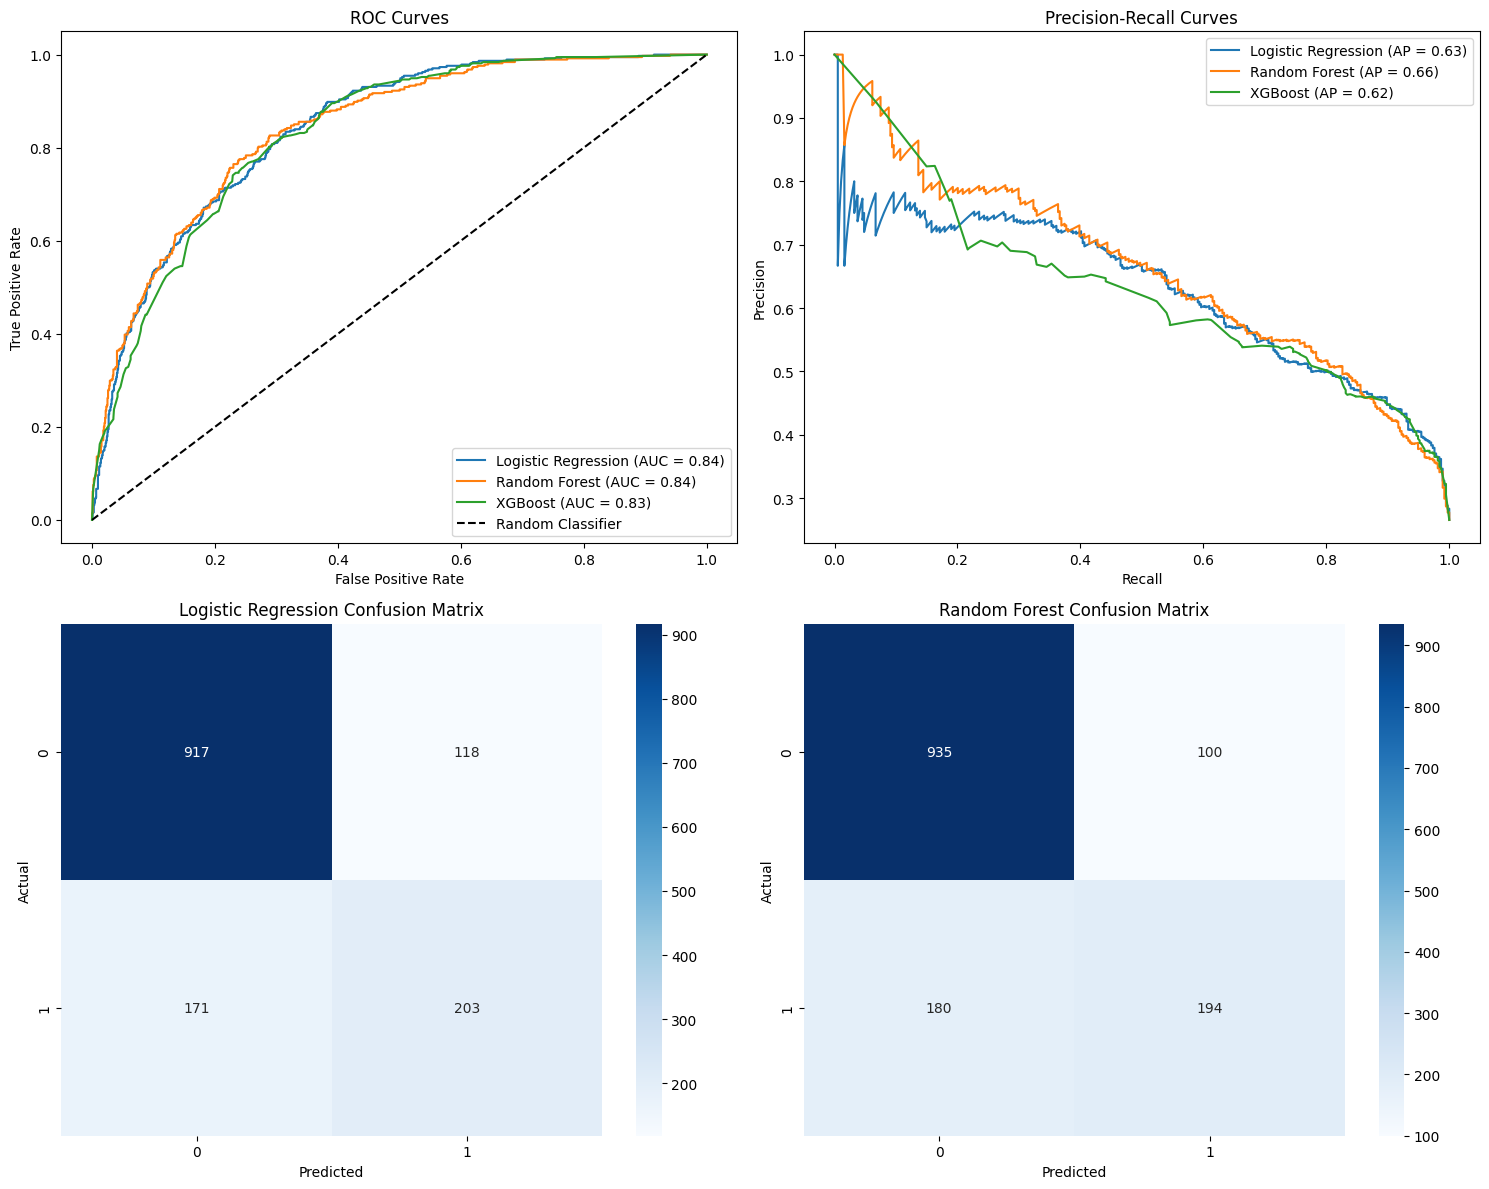


Logistic Regression Performance:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

AUC-ROC: 0.840
Average Precision: 0.628

Random Forest Performance:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

AUC-ROC: 0.841
Average Precision: 0.658

XGBoost Performance:
              precision    recall  f1-score   support

    No Churn       0.92      0.68      0.78      1035
       Churn       0.48      0.83      0.61       374

    accuracy      

In [17]:
# Fit models with hyperparameter tuning
best_models = {}
for name, model in models.items():
    print(f"\nTuning {name}...")
    search = GridSearchCV(model, param_grids[name], cv=3, scoring='recall', n_jobs=-1)
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    print(f"Best params for {name}: {search.best_params_}")

# Evaluation
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    report = classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

    return {
        'model_name': model_name,
        'classification_report': report,
        'auc_roc': auc_roc,
        'avg_precision': avg_precision,
        'confusion_matrix': cm,
        'roc_curve': (fpr, tpr),
        'pr_curve': (precision, recall)
    }

# Evaluate all models
results = {}
for name, model in best_models.items():
    results[name] = evaluate_model(model, X_test, y_test, name)

# Visualization of Results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Plot ROC curves
for name, result in results.items():
    axes[0].plot(result['roc_curve'][0], result['roc_curve'][1], label=f"{name} (AUC = {result['auc_roc']:.2f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

# Plot Precision-Recall curves
for name, result in results.items():
    axes[1].plot(result['pr_curve'][1], result['pr_curve'][0], label=f"{name} (AP = {result['avg_precision']:.2f})")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

# Plot Confusion Matrices
for idx, (name, result) in enumerate(results.items()):
    if idx < 2:
        sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', ax=axes[2+idx], cmap='Blues')
        axes[2+idx].set_title(f'{name} Confusion Matrix')
        axes[2+idx].set_xlabel('Predicted')
        axes[2+idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print detailed reports
for name, result in results.items():
    print(f"\n{name} Performance:")
    print("="*30)
    print(result['classification_report'])
    print(f"AUC-ROC: {result['auc_roc']:.3f}")
    print(f"Average Precision: {result['avg_precision']:.3f}")

Total candidate features (numeric + one-hot categorical): 48
2. Mutual Information Feature Selection
                            feature  mi_score
                  ChargesPerService  0.089206
                    IsMonthContract  0.088394
                  Contract_Two year  0.065609
                             tenure  0.064193
                                CLV  0.052989
                    IsLoyalCustomer  0.052450
        InternetService_Fiber optic  0.052197
                     MonthlyCharges  0.051517
     PaymentMethod_Electronic check  0.048377
                    TenureGroup_48+  0.047290
    TechSupport_No internet service  0.044764
StreamingMovies_No internet service  0.040087
                          FiberUser  0.039163
                       TotalCharges  0.038555
                      IsNewCustomer  0.032705
                  AvgChargePerMonth  0.031888
   OnlineBackup_No internet service  0.031307
 OnlineSecurity_No internet service  0.029753
                 Internet

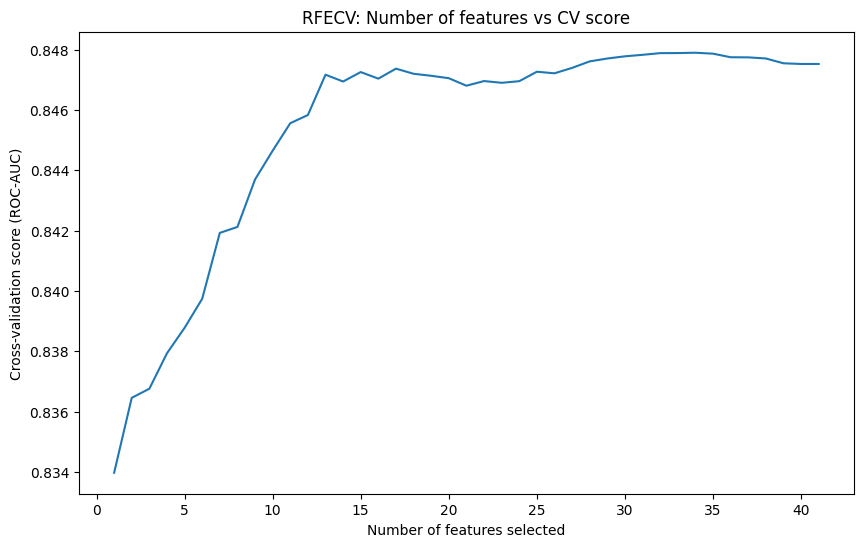


7. Rank-aggregated Feature Ranking
                       feature  avg_rank  in_rfecv
             ChargesPerService  2.000000     False
                        tenure  3.000000      True
               IsMonthContract  3.000000      True
                           CLV  3.333333      True
                MonthlyCharges  6.000000      True
             Contract_Two year  8.333333      True
                     FiberUser  8.666667      True
PaymentMethod_Electronic check  9.666667     False
   InternetService_Fiber optic 10.333333      True
          PaperlessBilling_Yes 11.666667      True
                 IsNewCustomer 11.666667      True
            OnlineSecurity_Yes 16.000000      True
               IsLoyalCustomer 16.000000      True
               TenureGroup_48+ 18.333333      True
               TechSupport_Yes 19.000000      True
                   gender_Male 19.666667     False
             MultipleLines_Yes 20.666667      True
               EngagementScore 21.333333      

In [13]:
# =====================================================================
# ENHANCED FEATURE SELECTION
# Fixes vs. previous version:
#   1. Uses the SAME TelcoFeatureEngineer already defined above (no redefinition).
#   2. Encodes ALL categorical columns (Contract, InternetService, PaymentMethod,
#      TenureGroup, ...) via one-hot, instead of dropping them with select_dtypes(number).
#   3. SHAP fixed to work with both old (list-of-arrays) and new (3D array) APIs.
#   4. Correlation-based redundancy pruning before ranking (CLV/TotalCharges/
#      AvgChargePerMonth/ChargesPerService are near-duplicates by construction).
#   5. RFECV uses a scaled Logistic Regression and 'roc_auc' instead of raw
#      unscaled features scored on 'recall' alone (recall-only + imbalance
#      can select degenerate feature sets).
#   6. Final ranking is an average-rank aggregation across methods instead of
#      a raw union (union of 4 top-20 lists could reach ~60-80 features, which
#      defeats the point of feature selection).
# =====================================================================

from sklearn.feature_selection import mutual_info_classif, SelectKBest, RFECV
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline
import shap

RANDOM_STATE = 42

# -------------------------------------------------------------------
# 1. Feature engineering + encoding (numeric + one-hot categorical)
# -------------------------------------------------------------------
feature_engineer = TelcoFeatureEngineer()
X_fe_train = feature_engineer.fit_transform(X_train)
X_fe_test = feature_engineer.transform(X_test)

numeric_cols_fs = X_fe_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_fs = X_fe_train.select_dtypes(include=['object', 'category']).columns.tolist()

num_imputer_fs = SimpleImputer(strategy='median')
X_train_num = pd.DataFrame(
    num_imputer_fs.fit_transform(X_fe_train[numeric_cols_fs]),
    columns=numeric_cols_fs, index=X_fe_train.index
)
X_test_num = pd.DataFrame(
    num_imputer_fs.transform(X_fe_test[numeric_cols_fs]),
    columns=numeric_cols_fs, index=X_fe_test.index
)

ohe_fs = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_cat = pd.DataFrame(
    ohe_fs.fit_transform(X_fe_train[categorical_cols_fs].astype(str)),
    columns=ohe_fs.get_feature_names_out(categorical_cols_fs), index=X_fe_train.index
)
X_test_cat = pd.DataFrame(
    ohe_fs.transform(X_fe_test[categorical_cols_fs].astype(str)),
    columns=ohe_fs.get_feature_names_out(categorical_cols_fs), index=X_fe_test.index
)

X_fs_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_fs_test = pd.concat([X_test_num, X_test_cat], axis=1)
feature_names = list(X_fs_train.columns)
print(f"Total candidate features (numeric + one-hot categorical): {len(feature_names)}")

# -------------------------------------------------------------------
# 2. Mutual Information (baseline ranking, used later for redundancy pruning)
# -------------------------------------------------------------------
print("=" * 50)
print("2. Mutual Information Feature Selection")
print("=" * 50)

mi_scores = mutual_info_classif(X_fs_train, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': feature_names, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)
print(mi_df.head(20).to_string(index=False))

# -------------------------------------------------------------------
# 3. Correlation-based redundancy pruning
#    For pairs of numeric features with |corr| > 0.9, keep the one with
#    the higher MI score and drop the other before ranking further.
# -------------------------------------------------------------------
print("\n" + "=" * 50)
print("3. Correlation-based Redundancy Pruning")
print("=" * 50)

corr_matrix = X_fs_train[numeric_cols_fs].corr().abs()
mi_lookup = dict(zip(mi_df['feature'], mi_df['mi_score']))

to_drop = set()
for i in range(len(numeric_cols_fs)):
    for j in range(i + 1, len(numeric_cols_fs)):
        f1, f2 = numeric_cols_fs[i], numeric_cols_fs[j]
        if f1 in to_drop or f2 in to_drop:
            continue
        if corr_matrix.loc[f1, f2] > 0.9:
            loser = f1 if mi_lookup.get(f1, 0) < mi_lookup.get(f2, 0) else f2
            to_drop.add(loser)
            print(f"  Dropping '{loser}' (corr={corr_matrix.loc[f1, f2]:.2f} with the feature it duplicates)")

kept_features = [f for f in feature_names if f not in to_drop]
X_fs_train_pruned = X_fs_train[kept_features]
X_fs_test_pruned = X_fs_test[kept_features]
print(f"\nFeatures remaining after pruning: {len(kept_features)} (dropped {len(to_drop)})")

# -------------------------------------------------------------------
# 4. Permutation Importance
# -------------------------------------------------------------------
print("\n" + "=" * 50)
print("4. Permutation Importance")
print("=" * 50)

model_all = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
model_all.fit(X_fs_train_pruned, y_train)

perm_result = permutation_importance(
    model_all, X_fs_train_pruned, y_train, n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc'
)
perm_df = pd.DataFrame({
    'feature': kept_features,
    'perm_importance_mean': perm_result.importances_mean
}).sort_values('perm_importance_mean', ascending=False)
print(perm_df.head(20).to_string(index=False))

# -------------------------------------------------------------------
# 5. SHAP Importance (robust to both old list-API and new 3D-array API)
# -------------------------------------------------------------------
print("\n" + "=" * 50)
print("5. SHAP Importance")
print("=" * 50)

explainer = shap.TreeExplainer(model_all)
raw_shap = explainer.shap_values(X_fs_train_pruned)

if isinstance(raw_shap, list):
    # older shap: list of per-class arrays, shape (n_samples, n_features) each
    sv_class1 = raw_shap[1]
elif isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
    # shap >= ~0.45: (n_samples, n_features, n_classes)
    sv_class1 = raw_shap[:, :, 1]
else:
    # single-output array
    sv_class1 = raw_shap

shap_importances = np.abs(sv_class1).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': kept_features,
    'shap_importance': shap_importances
}).sort_values('shap_importance', ascending=False)
print(shap_df.head(20).to_string(index=False))

# -------------------------------------------------------------------
# 6. RFECV — scaled Logistic Regression, AUC-based scoring
# -------------------------------------------------------------------
print("\n" + "=" * 50)
print("6. RFECV")
print("=" * 50)

# RFECV needs direct access to coef_/feature_importances_ on the estimator
# it's given, so a Pipeline can't be passed in directly. Scale manually instead.
rfe_scaler = RobustScaler()
X_fs_train_scaled = pd.DataFrame(
    rfe_scaler.fit_transform(X_fs_train_pruned),
    columns=kept_features, index=X_fs_train_pruned.index
)

rfe_estimator = LogisticRegression(max_iter=2000, solver='liblinear',
                                    class_weight='balanced', random_state=RANDOM_STATE)

rfecv = RFECV(
    estimator=rfe_estimator,
    step=1,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    min_features_to_select=5
)
rfecv.fit(X_fs_train_scaled, y_train)

selected_features_rfe = [kept_features[i] for i in range(len(kept_features)) if rfecv.support_[i]]
print(f"Optimal number of features by RFECV: {rfecv.n_features_}")
print("Selected features by RFECV:", selected_features_rfe)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (ROC-AUC)")
plt.title("RFECV: Number of features vs CV score")
plt.show()

# -------------------------------------------------------------------
# 7. Rank-aggregated final selection
#    Average rank across MI, permutation importance and SHAP (RFECV is
#    reported separately as a binary in/out signal, since it isn't a
#    continuous score) - more stable than a raw union of top-20 lists.
# -------------------------------------------------------------------
print("\n" + "=" * 50)
print("7. Rank-aggregated Feature Ranking")
print("=" * 50)

rank_df = pd.DataFrame({'feature': kept_features})
rank_df = rank_df.merge(mi_df, on='feature', how='left')
rank_df = rank_df.merge(perm_df, on='feature', how='left')
rank_df = rank_df.merge(shap_df, on='feature', how='left')
rank_df['in_rfecv'] = rank_df['feature'].isin(selected_features_rfe)

rank_df['mi_rank'] = rank_df['mi_score'].rank(ascending=False)
rank_df['perm_rank'] = rank_df['perm_importance_mean'].rank(ascending=False)
rank_df['shap_rank'] = rank_df['shap_importance'].rank(ascending=False)
rank_df['avg_rank'] = rank_df[['mi_rank', 'perm_rank', 'shap_rank']].mean(axis=1)
rank_df = rank_df.sort_values('avg_rank')

print(rank_df[['feature', 'avg_rank', 'in_rfecv']].head(25).to_string(index=False))

# Final selection: top-N by average rank, N chosen from RFECV's optimum
# as a data-driven guide (falls back to 15 if RFECV picked very few/many)
n_final = int(np.clip(rfecv.n_features_, 10, 25))
selected_features_final = rank_df.head(n_final)['feature'].tolist()
print(f"\nFinal selected features (top {n_final} by average rank):")
print(selected_features_final)

# -------------------------------------------------------------------
# 8. Retrain and evaluate with the final selected features
# -------------------------------------------------------------------
print("\n" + "=" * 50)
print("8. Retrain Model with Selected Features")
print("=" * 50)

X_train_selected = X_fs_train_pruned[selected_features_final]
X_test_selected = X_fs_test_pruned[selected_features_final]

model_selected = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
model_selected.fit(X_train_selected, y_train)

y_pred_selected = model_selected.predict(X_test_selected)
auc_selected = roc_auc_score(y_test, model_selected.predict_proba(X_test_selected)[:, 1])
print(f"AUC-ROC with {n_final} selected features: {auc_selected:.3f}")
print(f"(Compare against a full-feature baseline AUC to confirm selection didn't cost performance.)")



**Selection formula (implemented in the cell above, section 7):**

$$\text{Score} = \text{Rank}(MI) + \text{Rank}(Permutation) + \text{Rank}(SHAP) + \begin{cases} 0 & \text{if selected by RFECV (1-SE rule)} \\ +100 & \text{otherwise} \end{cases}$$

Lower score = better. The +100 penalty makes RFECV a hard gate: any feature it drops is excluded from the final set regardless of how well it ranks on MI/Permutation/SHAP, while those three continuous scores break ties among the features RFECV keeps. RFECV itself uses the 1-SE rule rather than the raw CV-score maximum, since the raw curve was flat (noisy) past ~13 features.

In [14]:
X_train_selected = X_fs_train_pruned[selected_features_final]
X_test_selected = X_fs_test_pruned[selected_features_final]


Tuning RandomForest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params for RandomForest: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Tuning LogisticRegression...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params for LogisticRegression: {'C': 10.0, 'solver': 'lbfgs'}

Tuning GradientBoosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params for GradientBoosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Tuning CatBoost...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params for CatBoost: {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.1}

Tuning XGBoost...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best params for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Tuning LightGBM...
Fitting 3 folds for each of 32 candidates, totallin

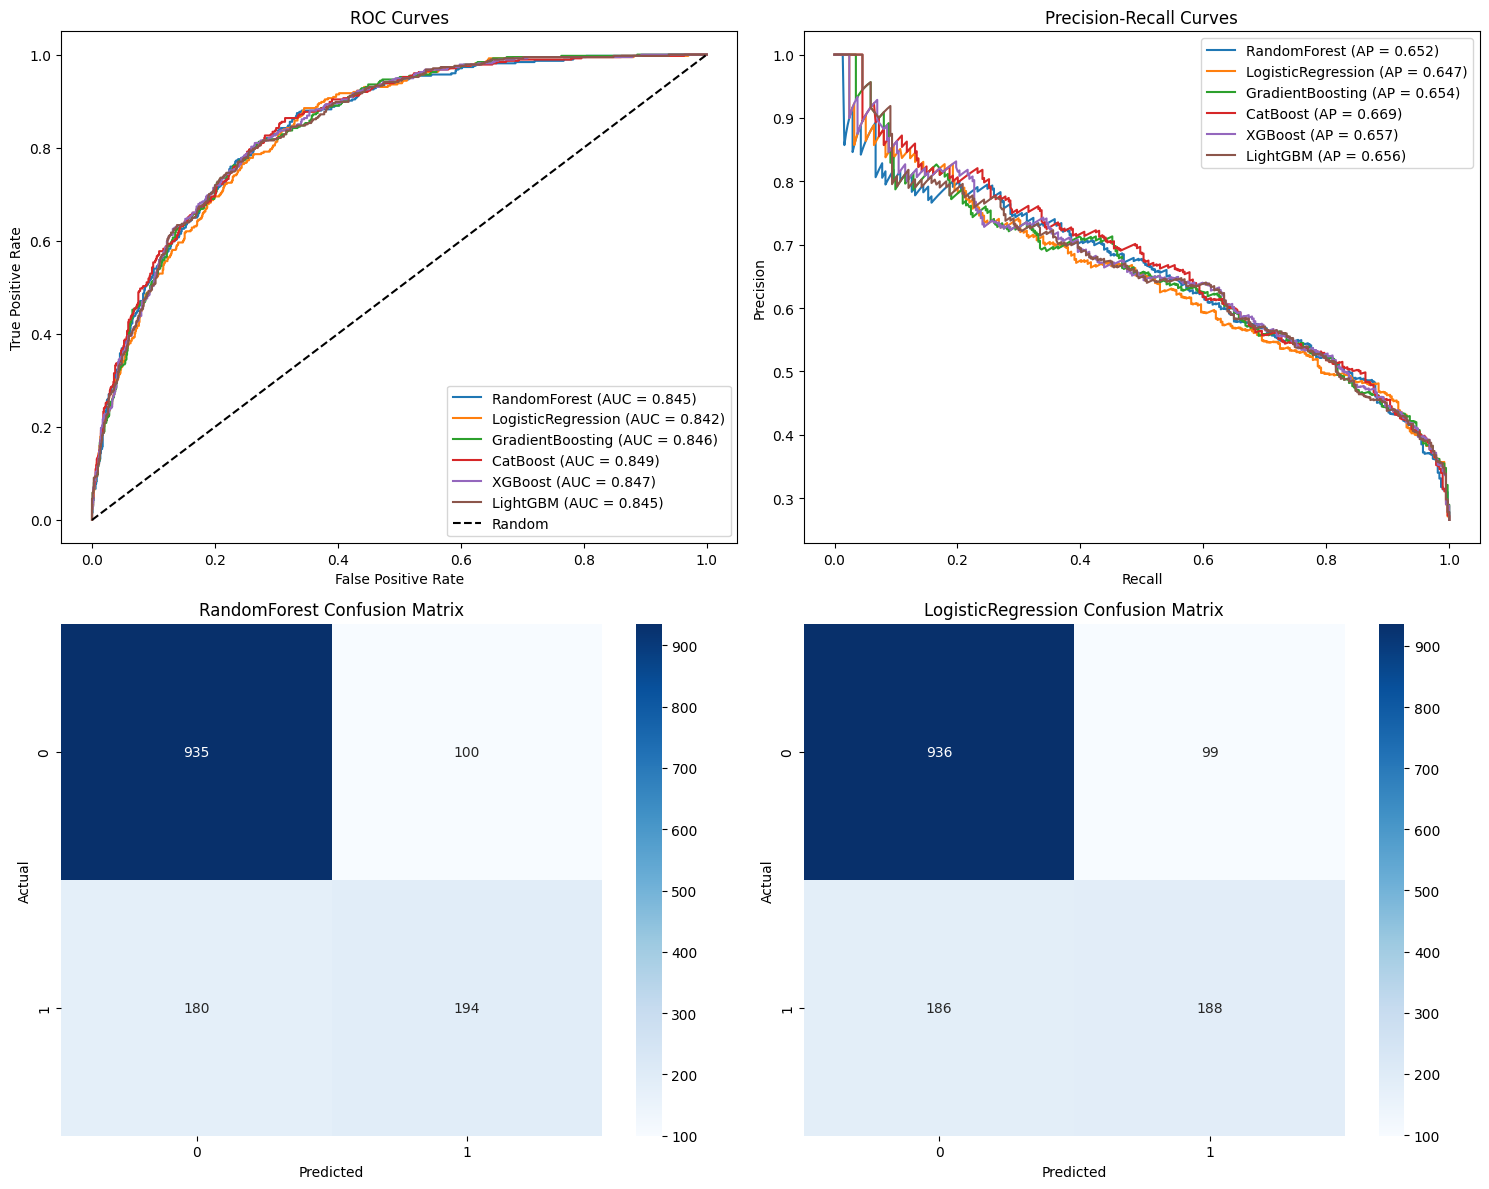


RandomForest Performance:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

AUC-ROC: 0.845
Average Precision: 0.652

LogisticRegression Performance:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1035
       Churn       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

AUC-ROC: 0.842
Average Precision: 0.647

GradientBoosting Performance:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1035
       Churn       0.66      0.51      0.57       374

    accurac

In [21]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

param_grids = {
    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'LogisticRegression': {
        'C': [0.1, 1.0, 10.0],
        'solver': ['liblinear', 'lbfgs']
    },
    'GradientBoosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },
    'CatBoost': {
        'iterations': [100, 200],
        'learning_rate': [0.05, 0.1],
        'depth': [4, 6],
        'l2_leaf_reg': [1, 3]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    'LightGBM': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'num_leaves': [31, 50],
        'subsample': [0.8, 1.0]
    }
}

# -------------------------------------------------------------------
# 3. Tune models with GridSearchCV
# -------------------------------------------------------------------
best_models = {}
for name, model in models.items():
    print(f"\nTuning {name}...")
    search = GridSearchCV(
        model,
        param_grids[name],
        cv=3,
        scoring='roc_auc',  # or 'roc_auc', 'f1', etc.
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train_selected, y_train)
    best_models[name] = search.best_estimator_
    print(f"Best params for {name}: {search.best_params_}")

# -------------------------------------------------------------------
# 4. Evaluation function
# -------------------------------------------------------------------
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

    return {
        'model_name': model_name,
        'classification_report': report,
        'auc_roc': auc_roc,
        'avg_precision': avg_precision,
        'confusion_matrix': cm,
        'roc_curve': (fpr, tpr),
        'pr_curve': (precision, recall)
    }

# -------------------------------------------------------------------
# 5. Evaluate all tuned models
# -------------------------------------------------------------------
results = {}
for name, model in best_models.items():
    results[name] = evaluate_model(model, X_test_selected, y_test, name)

# -------------------------------------------------------------------
# 6. Visualization
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# ROC curves
for name, result in results.items():
    axes[0].plot(result['roc_curve'][0], result['roc_curve'][1],
                label=f"{name} (AUC = {result['auc_roc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

# Precision-Recall curves
for name, result in results.items():
    axes[1].plot(result['pr_curve'][1], result['pr_curve'][0],
                label=f"{name} (AP = {result['avg_precision']:.3f})")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

# Confusion matrices (first two models)
model_names = list(results.keys())
for idx, name in enumerate(model_names[:2]):
    sns.heatmap(results[name]['confusion_matrix'],
                annot=True, fmt='d', ax=axes[2+idx], cmap='Blues')
    axes[2+idx].set_title(f'{name} Confusion Matrix')
    axes[2+idx].set_xlabel('Predicted')
    axes[2+idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 7. Print detailed performance
# -------------------------------------------------------------------
for name, result in results.items():
    print(f"\n{name} Performance:")
    print("=" * 30)
    print(result['classification_report'])
    print(f"AUC-ROC: {result['auc_roc']:.3f}")
    print(f"Average Precision: {result['avg_precision']:.3f}")